# Annotation in Scanpy

In [7]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [8]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.3] # This takes a while per res

2025-01-28 16:55:57,814 - INFO - Plate variable detected: plate1
2025-01-28 16:55:57,816 - INFO - Processing plate: plate1



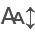

2025-01-28 16:55:57,845 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-28 16:55:57,847 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-28 16:55:57,848 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-28 16:55:57,849 - INFO - Scanpy directory exists: True
2025-01-28 16:55:57,849 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-01-28 16:55:57,851 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-28 16:55:57,853 - INFO - Loading data ...


(5225, 587)

In [9]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = sc.read(scanpy_dir + f'adata_clusters.h5ad')
adata.shape

In [10]:
# Violin plots of gene expression

2025-01-28 16:55:58,120 - INFO - Plot Violin ...


Genes not found in dataset for gene set Nowak_fig4: C1QC, TTR, PECAM1, TBX18, OMG, CSPG5, GHR, FZD8, HJURP, CRYAB, HEPACAM, LMO1, LEF1, VEPH1, NEUROG1, NRN1, BEST3, PIF1, ASCL1, EOMES, CALB2, SP8, SST, LINCO1305, TAC3, LHX6, NDST4, SLN, RSPO3, KCNJ6, NEFM, NEFL, HCRTR2, CRYM, TRPM3, PKD1, NHLH1
Genes not found in dataset for gene set Poulio_fig1c: RGS5, CCL3, AIF1, ITM2A, CLDN5, ESAM, DLX1, DLX2, LHX6, DLX5, STMN2, NEUROD6, PPP1R17, SSTR2, EOMES, PENK, STMN2, NEUROD6, NEUROD6, POU2F2, HMGB2, SOX2, MKI67, PCNA, OLIG1, PDGFRA, VIM, SOX2, SLC1A3, HES1, HOPX
Genes not found in dataset for gene set Camer_PFC: GAD1, SLC17A7, EOMES, GLI3, OLIG1, MKI67, C3, ITM2A, SST, CALB2, SCGN, TLE3, FEZF2, CRYM, LHX2
Genes not found in dataset for gene set ExNs: BCL11B, TBR1, NEUROD6, CPNE8
Genes not found in dataset for gene set InNs: GAD1, GAD2, DLX1, DLX2, SOX6, CALB1, CALB2, LHX6, PROX1
Genes not found in dataset for gene set Oligos: MBP, MOG, PLP1, MAG, CNP, OLIG1, OLIG2
Genes not found in dataset fo

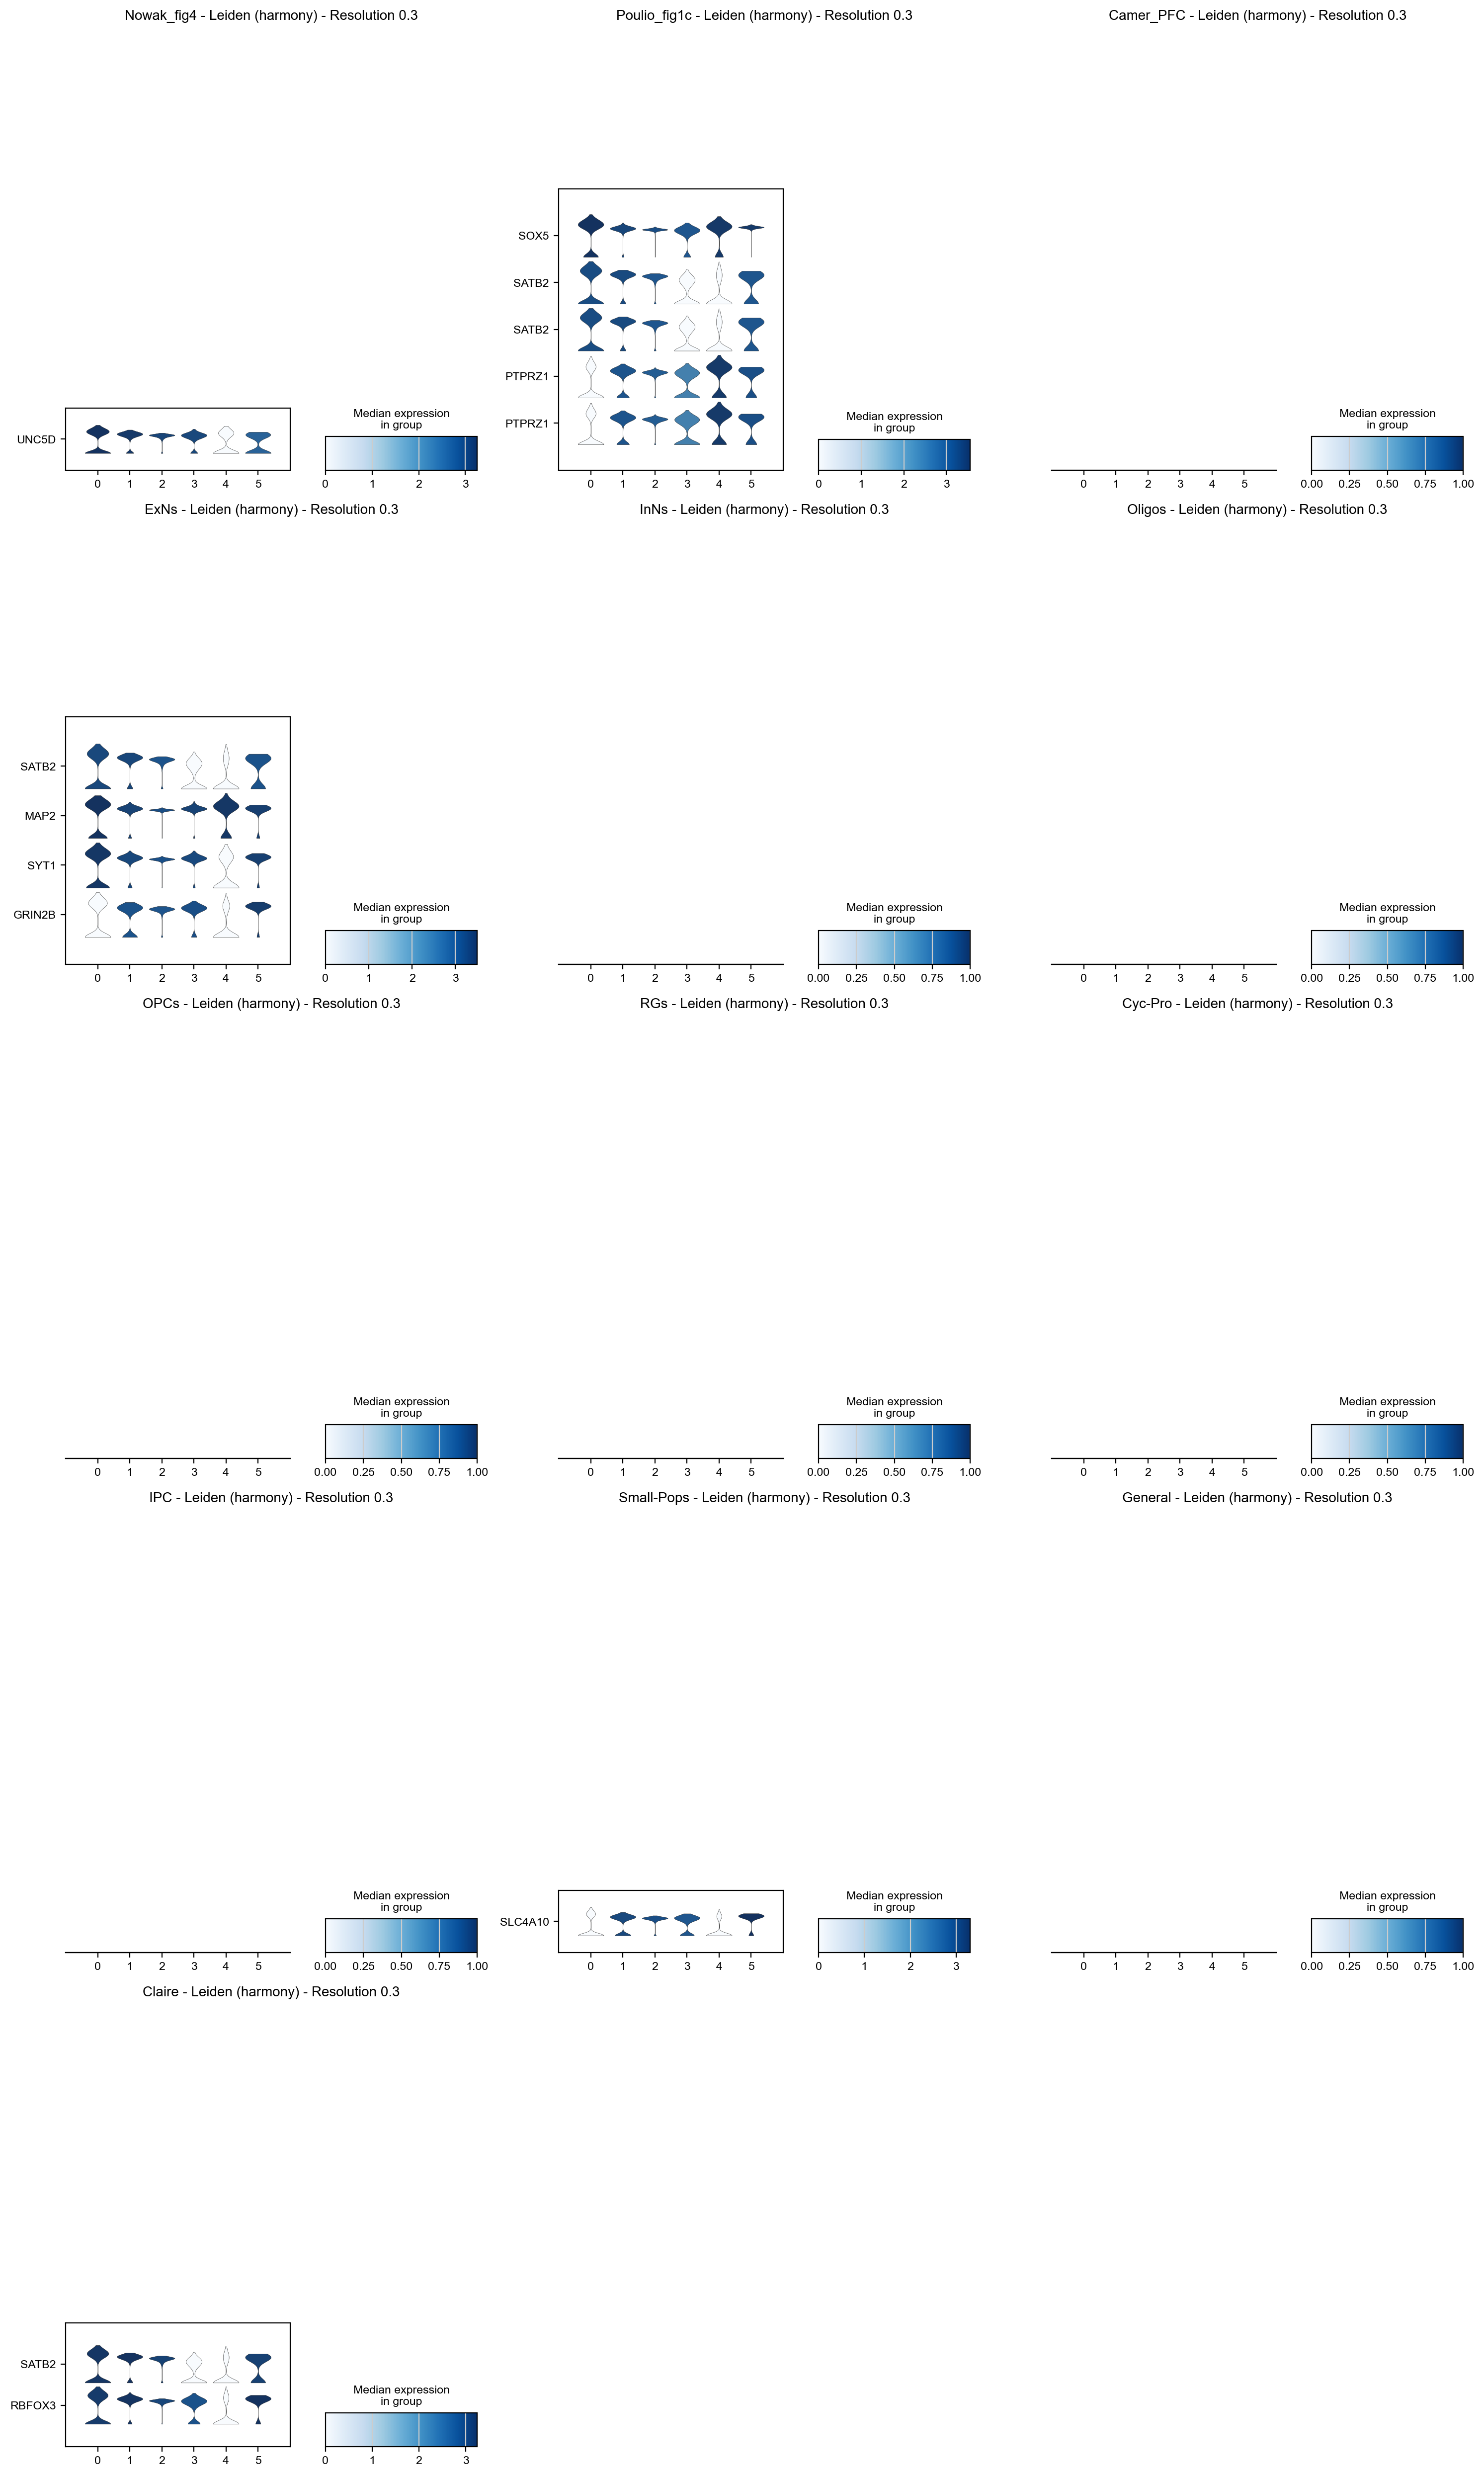

In [11]:
# Violin plots
logger.info("Plot Violin ...")
gene_sets = [("Nowak_fig4", Nowakowski_Fig4A_genes), 
             ("Poulio_fig1c", Pouliodakis_fig1c_genes), 
             ("Camer_PFC", pfc_features), 
             ("ExNs", exN_genes), 
             ("InNs", inN_genes),
                ("Oligos", olig_genes),
                ("OPCs", opc_genes),
                ("RGs", r_glia_genes),
                ("Cyc-Pro", cyc_pro_genes),
                ("IPC", ipc_genes),
                ("Small-Pops", small_populations),
                ("General", general_genes),
                ("Claire", claire_genes)]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden_harmony", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden (harmony)")
plt.show()  # Display the figure

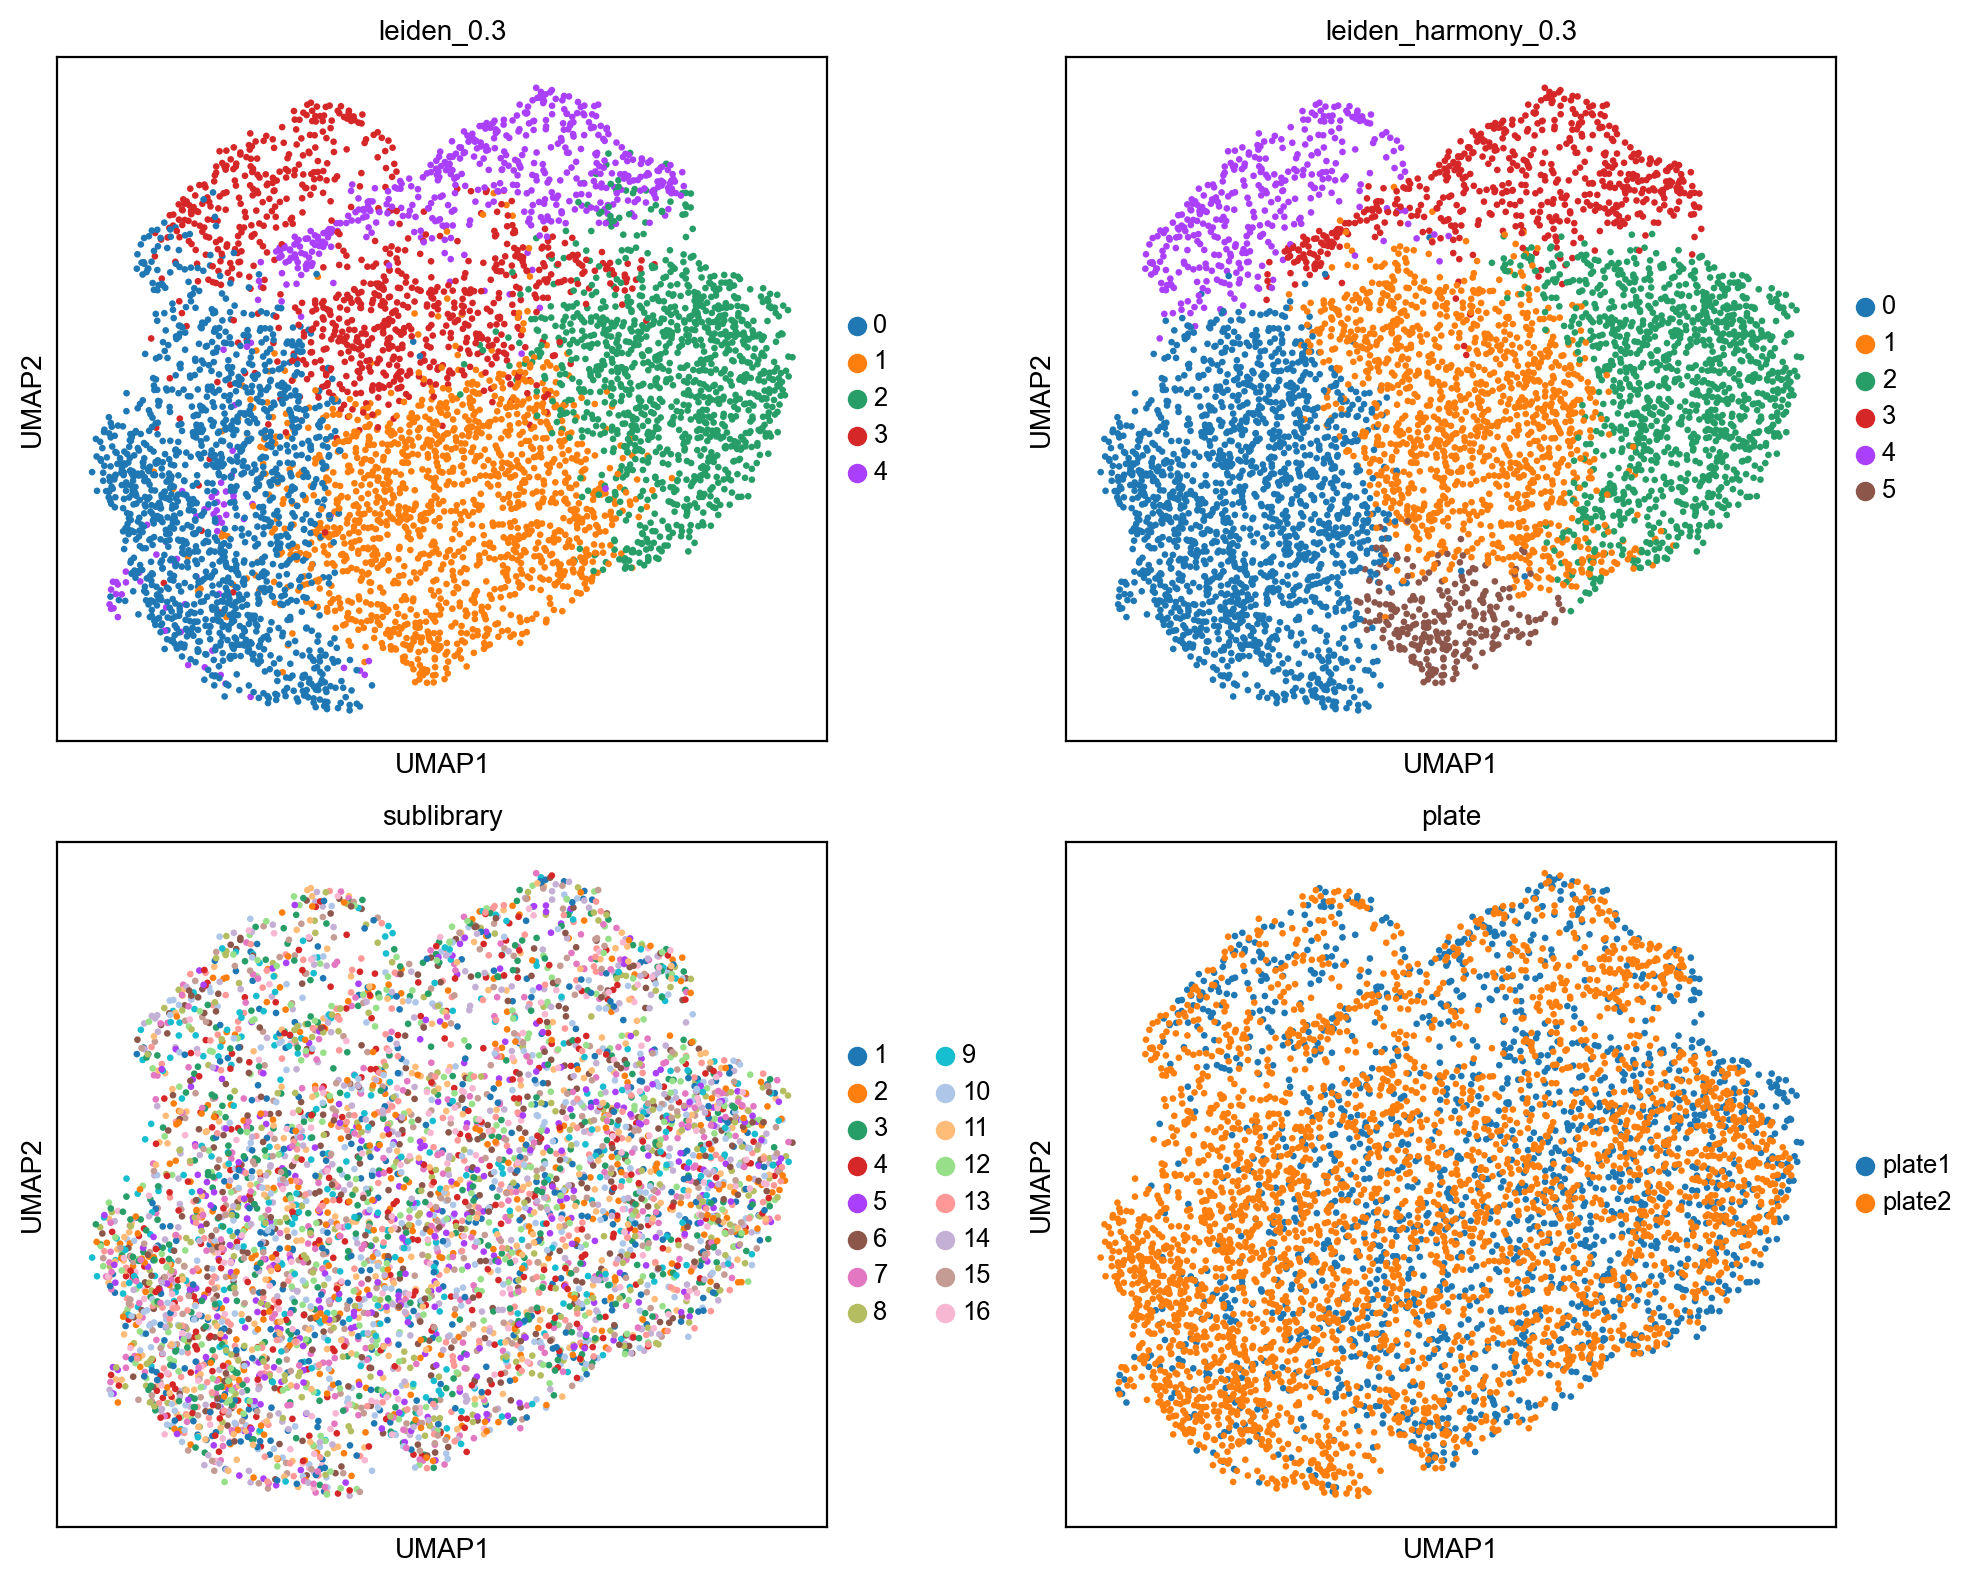

In [12]:
# UMAP
obs_columns = ['leiden_0.3', 'leiden_harmony_0.3', 'sublibrary', 'plate']
plot_umap_grid(adata, obs_columns, grid_size=(2, 2), figsize=(10, 8), save_path=None)
